# PHẦN 1: KHỞI TẠO VÀ ĐỌC DỮ LIỆU
Trong phần này, nhóm tiến hành gọi các thư viện cần thiết (Pandas, Matplotlib, Seaborn) và tải bộ dữ liệu thời tiết (weatherHistory.csv) vào hệ thống để chuẩn bị phân tích.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu
df = pd.read_csv('data/raw/weatherHistory.csv')
display(df.head(3))

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.


**Nhận xét Phần 1**
- **Dữ liệu đã được tải thành công. Cấu trúc bảng bao gồm các cột quan trọng như: Thời gian, Kiểu thời tiết (Summary), Loại lượng mưa (Precip Type), Nhiệt độ, Độ ẩm, Tốc độ gió...**

# PHẦN 2: KIỂM TRA TÌNH TRẠNG DỮ LIỆU
Bước tiếp theo, nhóm sẽ kiểm tra xem bộ dữ liệu này có đủ lớn không và có bị thiếu dữ liệu ở đâu không để tìm hướng khắc phục.

In [4]:
print(f"Tổng số dòng (bản ghi): {df.shape[0]:,}")
print(f"Tổng số cột (thuộc tính): {df.shape[1]}")

print("\nKiểm tra dữ liệu bị thiếu (Missing Values):")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Tổng số dòng (bản ghi): 96,453
Tổng số cột (thuộc tính): 12

Kiểm tra dữ liệu bị thiếu (Missing Values):
Precip Type    517
dtype: int64


**Nhận xét Phần 2:**
- **Khối lượng:** Bộ dữ liệu rất đồ sộ với hơn 96.000 bản ghi, hoàn toàn đáp ứng tốt cho việc huấn luyện AI.
- **Lỗi dữ liệu:** Phát hiện cột `Precip Type` (Loại lượng mưa) bị trống **517 dòng**. Nhóm sẽ phải dùng code để lấp đầy 517 lỗ hổng này ở giai đoạn Machine Learning sắp tới.

# PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU (EDA)
Nhóm sử dụng biểu đồ để tìm ra quy luật và mối liên hệ giữa các yếu tố thời tiết. Đặc biệt là tìm xem yếu tố nào ảnh hưởng mạnh nhất đến Nhiệt độ.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3504\207467571.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_weather.index, x=top_weather.values, palette='viridis')


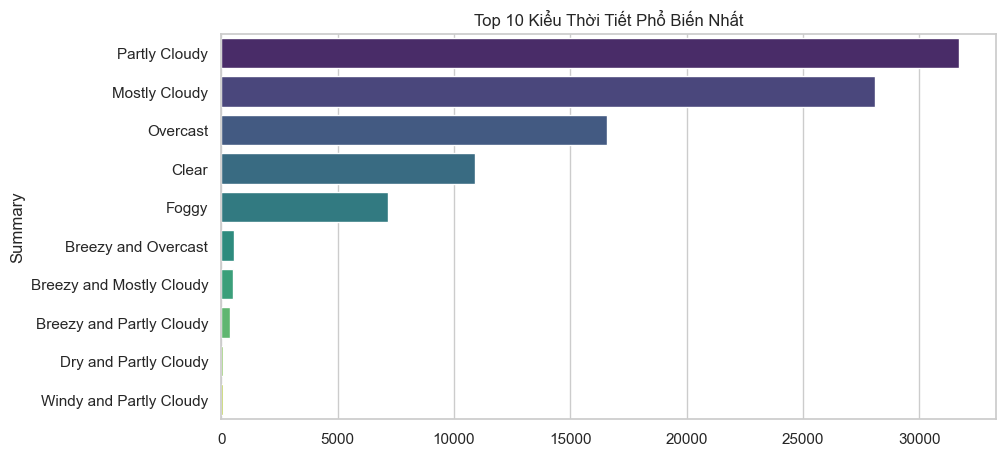

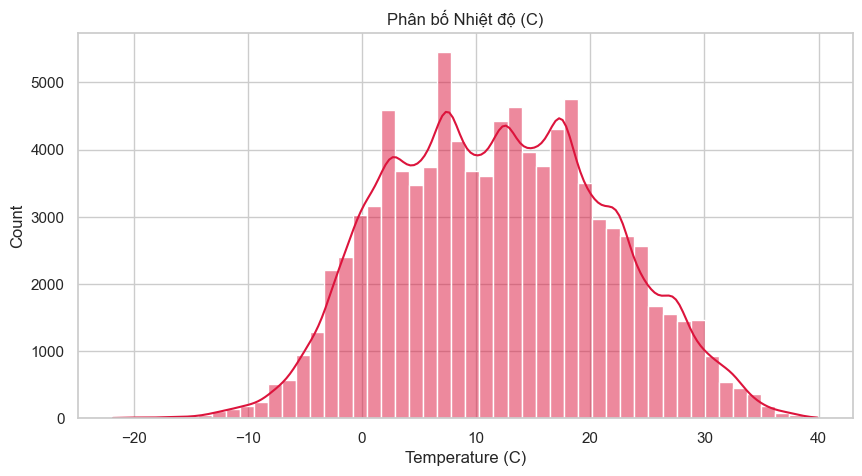

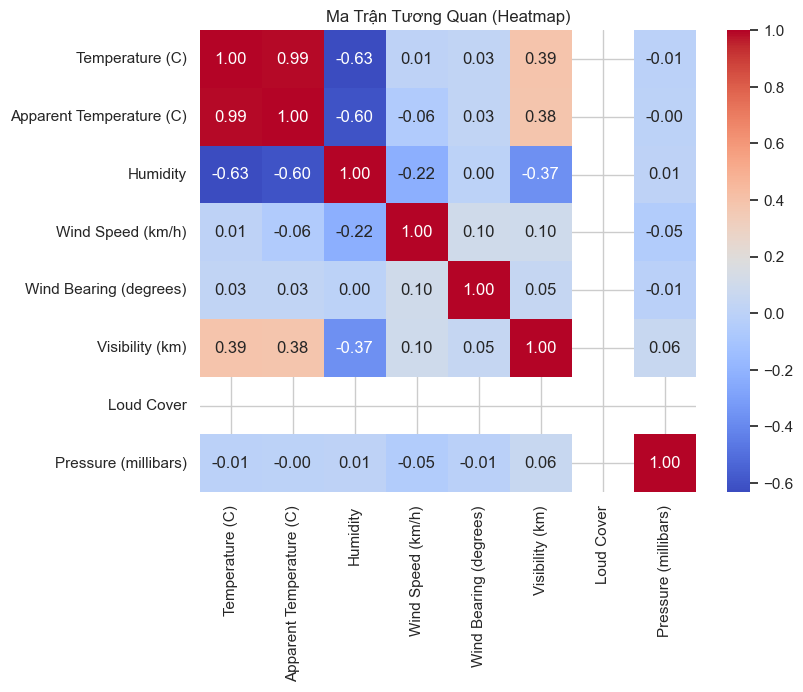

In [5]:
# 1. Biểu đồ Top 10 Kiểu thời tiết
plt.figure(figsize=(10, 5))
top_weather = df['Summary'].value_counts().head(10)
sns.barplot(y=top_weather.index, x=top_weather.values, palette='viridis')
plt.title('Top 10 Kiểu Thời Tiết Phổ Biến Nhất')
plt.show()

# 2. Phân bố Nhiệt độ
plt.figure(figsize=(10, 5))
sns.histplot(df['Temperature (C)'], bins=50, kde=True, color='crimson')
plt.title('Phân bố Nhiệt độ (C)')
plt.show()

# 3. Ma trận tương quan (Heatmap)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma Trận Tương Quan (Heatmap)')
plt.show()

**Nhận xét Phần 3:**
- **Biểu đồ 1:** Dữ liệu chủ yếu rơi vào các ngày thời tiết "Partly Cloudy" (Có mây từng phần) và "Mostly Cloudy".
- **Biểu đồ 2:** Nhiệt độ phân bố dạng hình chuông (Phân phối chuẩn), tập trung dày đặc nhất ở dải từ **10°C đến 20°C**.
- **Biểu đồ 3 (Quan trọng nhất):** Ma trận Heatmap chỉ ra rằng **Độ ẩm (Humidity)** có chỉ số tương quan là `-0.63` với Nhiệt độ. Đây là mối tương quan nghịch cực kỳ mạnh (Độ ẩm càng cao thì trời càng lạnh). 

**Kết luận EDA:** Dữ liệu hoàn toàn khả thi. Độ ẩm, Áp suất và Sức gió có liên kết chặt chẽ với Nhiệt độ.